# Joint GWT — Per-Expert Posterior Predictive Check

Validates the current joint multi-system GWT baseline (shared observation model, no expert shifts — notebook 12) with per-expert PPCs, then compares against a middle-ground **tight-prior expert-shift** variant (`Normal(0, 0.3)`).

## What we check
For each expert: observed vs posterior-predicted 7-bin rating histogram, mean rating, and proportion of extreme ratings (categories 1 and 7). The PPC replicates ratings from the mixture
$$P(r=k \mid s) = pz1_j^{(s)} \cdot P_{\rm OP}(k \mid b_e^{(s)} + a^{(s)}, \kappa^{(s)}) + (1 - pz1_j^{(s)}) \cdot P_{\rm OP}(k \mid b_e^{(s)}, \kappa^{(s)}),$$
using the data-conditioned indicator posterior `pz1_j` exposed by the joint builder. This is a conditional-predictive diagnostic — it answers *given our best guess at each indicator, can we reproduce this expert's rating distribution?*

## Acceptance criteria
1. Ordering Human >> Chicken > LLM > ELIZA preserved in the baseline.
2. No material divergences; R-hat OK.
3. No glaring one-sided category misfit per expert.
4. Tight-shift variant does **not** collapse back to Chicken ≈ LLM.

In [1]:
import os, sys, warnings, time

os.environ["PYTENSOR_FLAGS"] = f"compiledir=/tmp/pytensor_cache_nb13_{os.getpid()}"
sys.path.insert(0, "..")
os.chdir(os.path.join(os.path.dirname(os.path.abspath("."))))
warnings.filterwarnings("ignore", message="Loop fusion failed")

import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import string

from dcm_model import ModelConfig, load_data, fit_stance_multisystem
from dcm_ppc import (
    per_expert_ppc_multisystem,
    plot_per_expert_ppc,
    summarise_per_expert_ppc,
)

plt.rcParams.update(
    {"figure.dpi": 120, "font.size": 10, "figure.constrained_layout.use": True}
)

In [2]:
STANCE = "Global Workspace Theory"
SYSTEM_CONFIGS = [
    ("Human", 0.999),
    ("Chicken", None),
    ("2024 Leading Chat LLMs", None),
    ("ELIZA", 0.001),
]

all_data = load_data(ModelConfig())
stance_data = next(s for s in all_data if s["name"] == STANCE)

## 1. Baseline: no expert shifts (current validated joint model)

In [3]:
cfg_base = ModelConfig(
    USE_EXPERT_SHIFTS=False,
    NUM_SAMPLES=2000,
    NUM_TUNE=1500,
    NUM_CHAINS=4,
    TARGET_ACCEPT=0.9,
)

t0 = time.time()
idata_base, builder_base, proc_base = fit_stance_multisystem(
    stance_data, cfg_base, SYSTEM_CONFIGS
)
print(f"\nBaseline fit: {time.time() - t0:.0f}s")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [chicken__global_workspace_theory_C, 2024_leading_chat_llms__global_workspace_theory_C, a, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic_representations_beta_pres, isomorphic_representations_beta_abs, somatotopic_neural_maps_beta_pres, somato

Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 380 seconds.



Baseline fit: 4708s


In [ ]:
# Per-system C, diagnostics
stance_vn = builder_base.node_to_varname[STANCE]
post = idata_base.posterior

print("Per-system P(C=1 | data):")
for sys_name, c_fixed in SYSTEM_CONFIGS:
    sp = builder_base._sys_prefix(sys_name)
    c_key = f"{sp}__{stance_vn}_C"
    if c_key in post:
        d = post[c_key].values.flatten()
        print(
            f"  {sys_name:<25s}  {d.mean():.3f}  [{np.percentile(d, 3):.3f}, {np.percentile(d, 97):.3f}]"
        )
    else:
        print(f"  {sys_name:<25s}  {c_fixed:.3f}  (ref)")

n_div = int(idata_base.sample_stats["diverging"].values.sum())
summary = az.summary(idata_base, var_names=["a", "kappa"], kind="diagnostics")
print(
    f"\nDivergences: {n_div}   max R-hat: {float(summary['r_hat'].max()):.3f}   min ESS: {float(summary['ess_bulk'].min()):.0f}"
)
print(f"Shared a (discrimination): {float(post['a'].mean()):.3f}")

Per-system P(C=1 | data):
  Human                      0.999  [0.999, 0.999]
  Chicken                    0.273  [0.017, 0.655]
  2024 Leading Chat LLMs     0.109  [0.004, 0.361]
  ELIZA                      0.001  [0.001, 0.001]

Divergences: 0   max R-hat: 1.000   min ESS: 6220
Shared a (discrimination): 1.906


In [5]:
# Per-expert PPC
ppc_base = per_expert_ppc_multisystem(
    idata_base, builder_base, proc_base, n_draws=500, seed=0
)

anon_base = {
    name: f"Expert {letter}"
    for letter, name in zip(string.ascii_uppercase, proc_base.expert_names)
}

print(summarise_per_expert_ppc(ppc_base))

Expert                  n  obs_mean     pred_mean  obs_extr     pred_extr
-------------------------------------------------------------------------
Derek Shiller         150      2.89  3.38 [3.05,3.70]      0.72  0.46 [0.38,0.55]
Andreas Mogensen       40      3.00  3.03 [2.48,3.60]      0.47  0.46 [0.30,0.60]
Felix Binder           48      3.27  3.06 [2.52,3.60]      0.40  0.45 [0.31,0.60]
Hayley chickens        47      4.79  4.20 [3.70,4.66]      0.34  0.49 [0.36,0.62]
Luhan Mikaelson        48      3.71  3.04 [2.52,3.56]      0.17  0.45 [0.31,0.58]
Rachael Miller         46      4.22  4.19 [3.65,4.74]      0.15  0.49 [0.35,0.65]


/Users/ryankelly/ryan-code/research/dcm-code/dcm_ppc.py:312: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


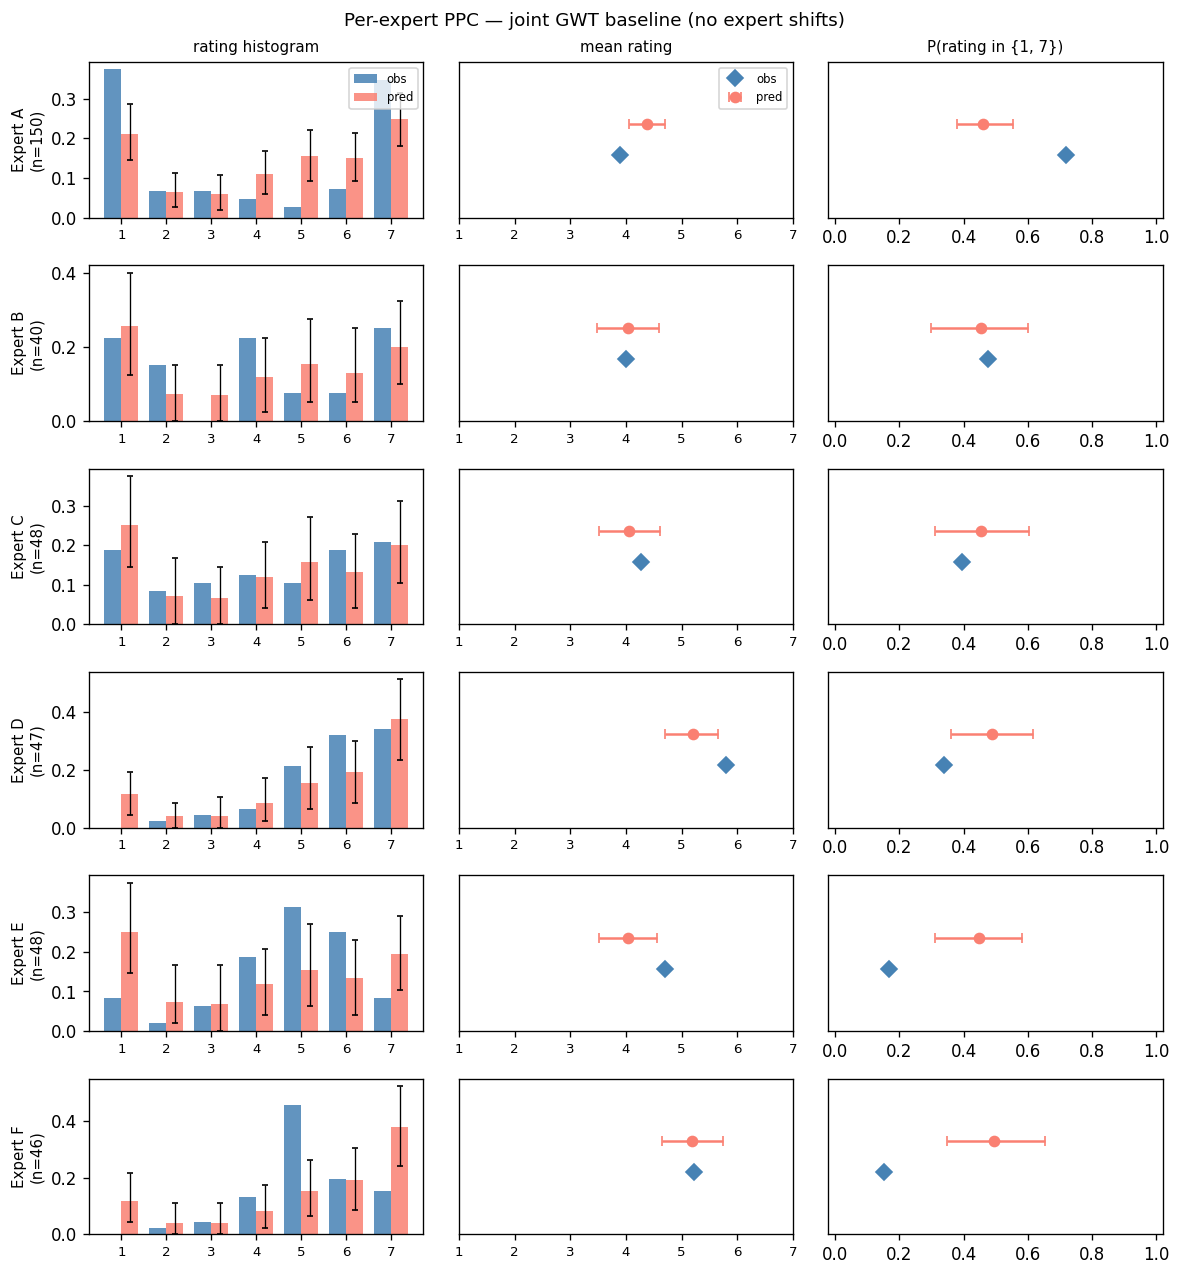

In [6]:
fig, _ = plot_per_expert_ppc(
    ppc_base,
    K=cfg_base.N_CATEGORIES,
    expert_display=anon_base,
    title="Per-expert PPC — joint GWT baseline (no expert shifts)",
)
os.makedirs("report_figures", exist_ok=True)
fig.savefig("report_figures/gwt_joint_per_expert_ppc_baseline.png", dpi=150)
plt.show()

## 2. Middle-ground variant: tight-prior expert shifts (sigma = 0.3)

Arvo's suggested follow-up. If the tight prior preserves the Chicken > LLM > ELIZA ordering *and* improves per-expert calibration, that supports reinstating a small expert-level location term as the default.

In [7]:
cfg_tight = ModelConfig(
    USE_EXPERT_SHIFTS=True,
    EXPERT_SHIFT_SIGMA=0.3,
    NUM_SAMPLES=2000,
    NUM_TUNE=1500,
    NUM_CHAINS=4,
    TARGET_ACCEPT=0.9,
)

t0 = time.time()
idata_tight, builder_tight, proc_tight = fit_stance_multisystem(
    stance_data, cfg_tight, SYSTEM_CONFIGS
)
print(f"\nTight-shift fit: {time.time() - t0:.0f}s")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [chicken__global_workspace_theory_C, 2024_leading_chat_llms__global_workspace_theory_C, a, b_free, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic_representations_beta_pres, isomorphic_representations_beta_abs, somatotopic_neural_maps_beta_pres

Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 444 seconds.



Tight-shift fit: 4985s


In [8]:
stance_vn = builder_tight.node_to_varname[STANCE]
post_t = idata_tight.posterior

print("Per-system P(C=1 | data) — tight shifts sigma=0.3:")
for sys_name, c_fixed in SYSTEM_CONFIGS:
    sp = builder_tight._sys_prefix(sys_name)
    c_key = f"{sp}__{stance_vn}_C"
    if c_key in post_t:
        d = post_t[c_key].values.flatten()
        print(
            f"  {sys_name:<25s}  {d.mean():.3f}  [{np.percentile(d, 3):.3f}, {np.percentile(d, 97):.3f}]"
        )
    else:
        print(f"  {sys_name:<25s}  {c_fixed:.3f}  (ref)")

n_div = int(idata_tight.sample_stats["diverging"].values.sum())
summary = az.summary(
    idata_tight, var_names=["a", "b_free", "kappa"], kind="diagnostics"
)
print(
    f"\nDivergences: {n_div}   max R-hat: {float(summary['r_hat'].max()):.3f}   min ESS: {float(summary['ess_bulk'].min()):.0f}"
)
print(
    f"Shared a: {float(post_t['a'].mean()):.3f}   b_free sd: {float(post_t['b_free'].std()):.3f}"
)

Per-system P(C=1 | data) — tight shifts sigma=0.3:
  Human                      0.999  [0.999, 0.999]
  Chicken                    0.275  [0.013, 0.668]
  2024 Leading Chat LLMs     0.100  [0.003, 0.342]
  ELIZA                      0.001  [0.001, 0.001]

Divergences: 0   max R-hat: 1.000   min ESS: 4057
Shared a: 2.118   b_free sd: 0.260


In [9]:
ppc_tight = per_expert_ppc_multisystem(
    idata_tight, builder_tight, proc_tight, n_draws=500, seed=0
)

anon_tight = {
    name: f"Expert {letter}"
    for letter, name in zip(string.ascii_uppercase, proc_tight.expert_names)
}

print(summarise_per_expert_ppc(ppc_tight))

Expert                  n  obs_mean     pred_mean  obs_extr     pred_extr
-------------------------------------------------------------------------
Derek Shiller         150      2.89  3.21 [2.88,3.55]      0.72  0.47 [0.39,0.55]
Andreas Mogensen       40      3.00  2.98 [2.33,3.62]      0.47  0.45 [0.30,0.60]
Felix Binder           48      3.27  3.19 [2.56,3.81]      0.40  0.44 [0.31,0.58]
Hayley chickens        47      4.79  4.48 [3.98,4.98]      0.34  0.53 [0.38,0.68]
Luhan Mikaelson        48      3.71  3.29 [2.73,3.92]      0.17  0.42 [0.29,0.56]
Rachael Miller         46      4.22  4.00 [3.41,4.59]      0.15  0.46 [0.30,0.63]


/Users/ryankelly/ryan-code/research/dcm-code/dcm_ppc.py:312: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


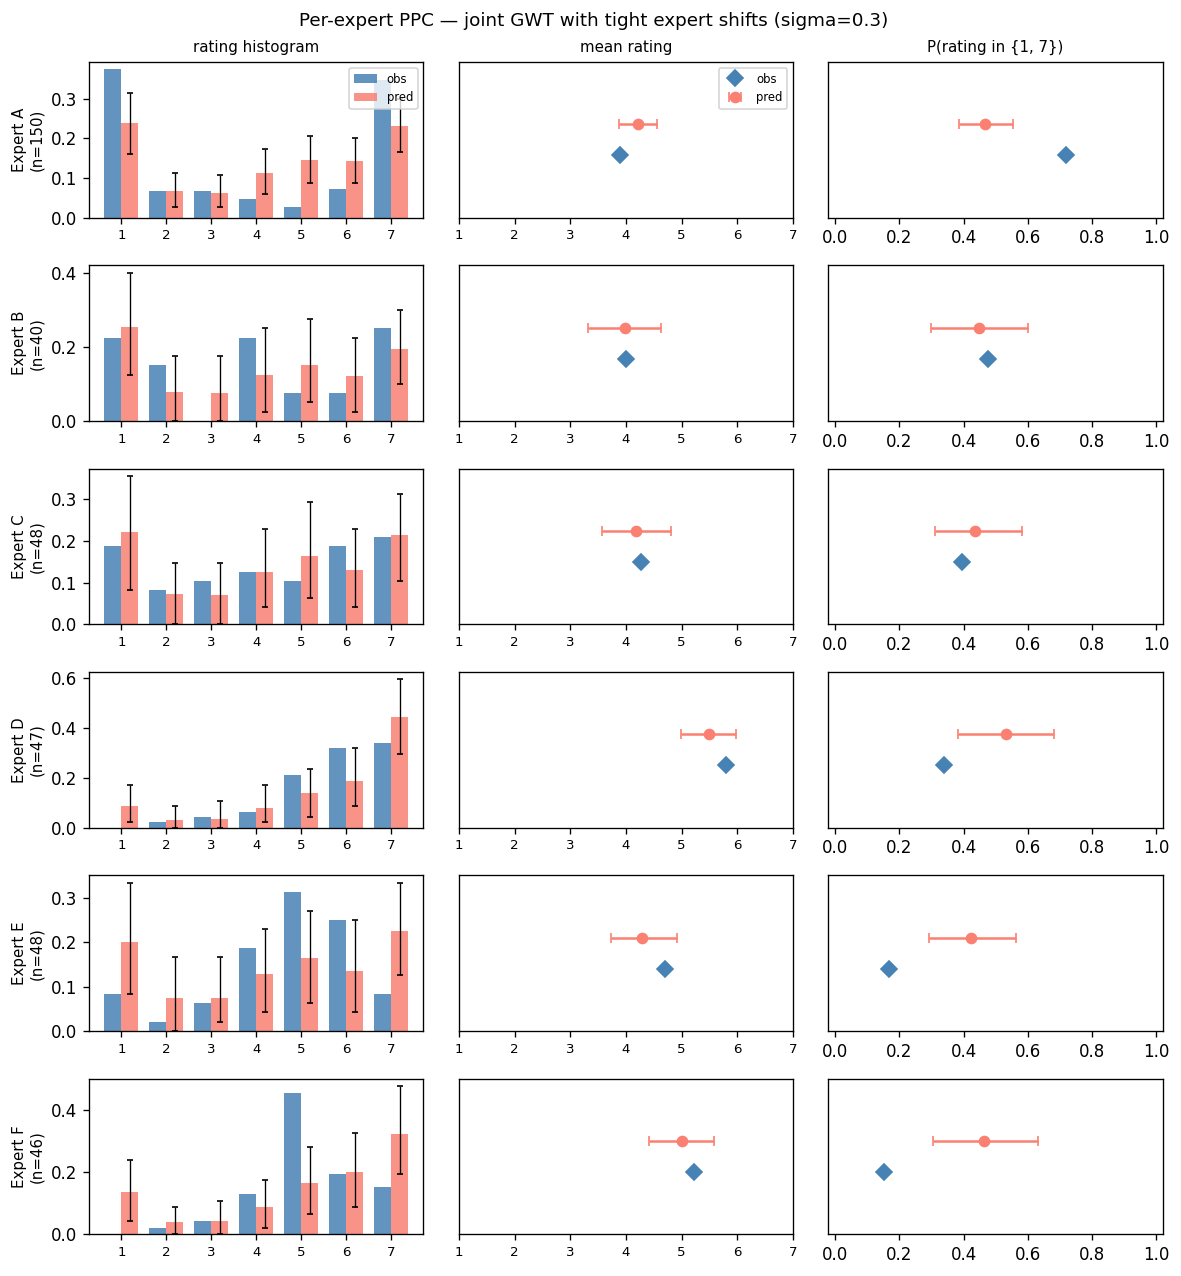

In [10]:
fig, _ = plot_per_expert_ppc(
    ppc_tight,
    K=cfg_tight.N_CATEGORIES,
    expert_display=anon_tight,
    title="Per-expert PPC — joint GWT with tight expert shifts (sigma=0.3)",
)
fig.savefig("report_figures/gwt_joint_per_expert_ppc_tight.png", dpi=150)
plt.show()

## 3. Baseline vs tight-shift side-by-side

Forest plot of per-system $P(C=1)$ under both models. The acceptance criterion is that the tight-shift variant still separates Chicken and LLMs.

In [ ]:
def extract_c(idata, builder):
    """Return point estimate and 94% CI per system.

    Use the posterior MEDIAN for the point estimate, not the mean. The median
    is guaranteed to lie inside [3%, 97%] so the errorbar arms are always
    non-negative; the mean can exit that interval for heavily skewed
    near-boundary posteriors (e.g. Chicken/LLMs under tight shifts with most
    mass near 0 and a long right tail).
    """
    vn = builder.node_to_varname[STANCE]
    out = {}
    for sys_name, c_fixed in SYSTEM_CONFIGS:
        sp = builder._sys_prefix(sys_name)
        key = f"{sp}__{vn}_C"
        if key in idata.posterior:
            d = idata.posterior[key].values.flatten()
            med = float(np.median(d))
            lo = float(np.percentile(d, 3))
            hi = float(np.percentile(d, 97))
            out[sys_name] = (med, lo, hi, False)
        else:
            out[sys_name] = (c_fixed, c_fixed, c_fixed, True)
    return out


c_base = extract_c(idata_base, builder_base)
c_tight = extract_c(idata_tight, builder_tight)

fig, ax = plt.subplots(figsize=(7, 3.5))
display_name = {"2024 Leading Chat LLMs": "LLMs (2024)"}
colours = {
    "Human": "forestgreen",
    "Chicken": "goldenrod",
    "2024 Leading Chat LLMs": "steelblue",
    "ELIZA": "salmon",
}
for i, (sys_name, _) in enumerate(SYSTEM_CONFIGS):
    lbl = display_name.get(sys_name, sys_name)
    col = colours[sys_name]
    mb, lb, hb, fb = c_base[sys_name]
    mt, lt, ht, ft = c_tight[sys_name]
    if fb:
        ax.plot(
            [mb],
            [i],
            "D",
            color=col,
            markersize=8,
            label=f"{lbl} (ref)" if i == 0 else None,
        )
    else:
        ax.errorbar(
            [mb],
            [i - 0.12],
            xerr=[[max(mb - lb, 0.0)], [max(hb - mb, 0.0)]],
            fmt="o",
            color=col,
            capsize=3,
            markersize=6,
            label=f"{lbl} baseline" if i == 1 else None,
        )
        ax.errorbar(
            [mt],
            [i + 0.12],
            xerr=[[max(mt - lt, 0.0)], [max(ht - mt, 0.0)]],
            fmt="s",
            color=col,
            capsize=3,
            markersize=6,
            alpha=0.6,
            label=f"{lbl} tight" if i == 1 else None,
        )
ax.set_yticks(range(len(SYSTEM_CONFIGS)))
ax.set_yticklabels([display_name.get(s, s) for s, _ in SYSTEM_CONFIGS])
ax.invert_yaxis()
ax.axvline(1 / 6, color="grey", linestyle=":", alpha=0.5, label="prior mean")
ax.set_xlabel(r"$P(C=1 \mid \mathrm{data})$ (posterior median)")
ax.set_xlim(-0.02, 1.05)
ax.set_title(
    "GWT joint fit — baseline (circle) vs tight shifts sigma=0.3 (square)", fontsize=10
)
ax.legend(fontsize=7, loc="center right")
fig.savefig("report_figures/gwt_joint_baseline_vs_tight.png", dpi=150)
plt.show()

## Interpretation checklist

**Baseline is OK if:**
- Human ≈ 1.0, ELIZA ≈ 0, Chicken > LLMs > 0.05, all with finite CIs.
- 0 divergences, max R-hat ≤ 1.01, min ESS ≥ ~300.
- For each expert: predicted histogram overlaps observed; no single category is mispredicted by >~0.15 one-sided; observed mean rating inside predicted 94% CI; observed extreme proportion inside predicted 94% CI.

**Tight-shift variant is acceptable if:**
- Ordering Chicken > LLMs preserved (key failure mode of the sigma=2 variant).
- Posterior `b_free` sd smaller than the prior sigma (i.e. shifts are data-informed, not prior-dominated).
- Per-expert PPC is at least as good as the baseline.

If those all hold, the tight-shift model is a defensible default — small expert calibration differences but not enough to absorb the system-level signal.

## 4. Stratified per-(expert, system) PPC

The pooled per-expert PPC in section 1 conflates two things: (a) an expert being more/less extreme in rating style, and (b) that expert having mostly rated systems at the ends of the consciousness scale (Human + ELIZA), where extreme ratings are expected a priori.

Stratifying by `(expert, system)` holds the system's indicator-presence distribution fixed within each cell. Any remaining histogram misfit in a cell is a real calibration issue for that expert on that system, not a coverage artefact.

This cell reloads `dcm_ppc` and calls the new helper on the already-fitted `idata_base` and `idata_tight`. Your existing kernel state (`idata_base`, `idata_tight`, `builder_*`, `proc_*`) is untouched.

In [6]:
import importlib
import dcm_ppc

importlib.reload(dcm_ppc)
from dcm_ppc import (
    per_expert_system_ppc_multisystem,
    plot_per_expert_system_histograms,
    summarise_per_expert_system_ppc,
)

SYSTEM_DISPLAY = {
    "Human": "Human",
    "Chicken": "Chicken",
    "2024 Leading Chat LLMs": "LLMs",
    "ELIZA": "ELIZA",
}
SYSTEM_ORDER = ["Human", "Chicken", "2024 Leading Chat LLMs", "ELIZA"]

### 4a. Stratified PPC — baseline (no expert shifts)

In [9]:
ppc_base_strat = per_expert_system_ppc_multisystem(
    idata_base, builder_base, proc_base, n_draws=500, seed=0
)
print(f"cells: {len(ppc_base_strat)}")
print(summarise_per_expert_system_ppc(ppc_base_strat))

NameError: name 'idata_base' is not defined

/Users/ryankelly/ryan-code/research/dcm-code/dcm_ppc.py:570: UserWarning: The figure layout has changed to tight


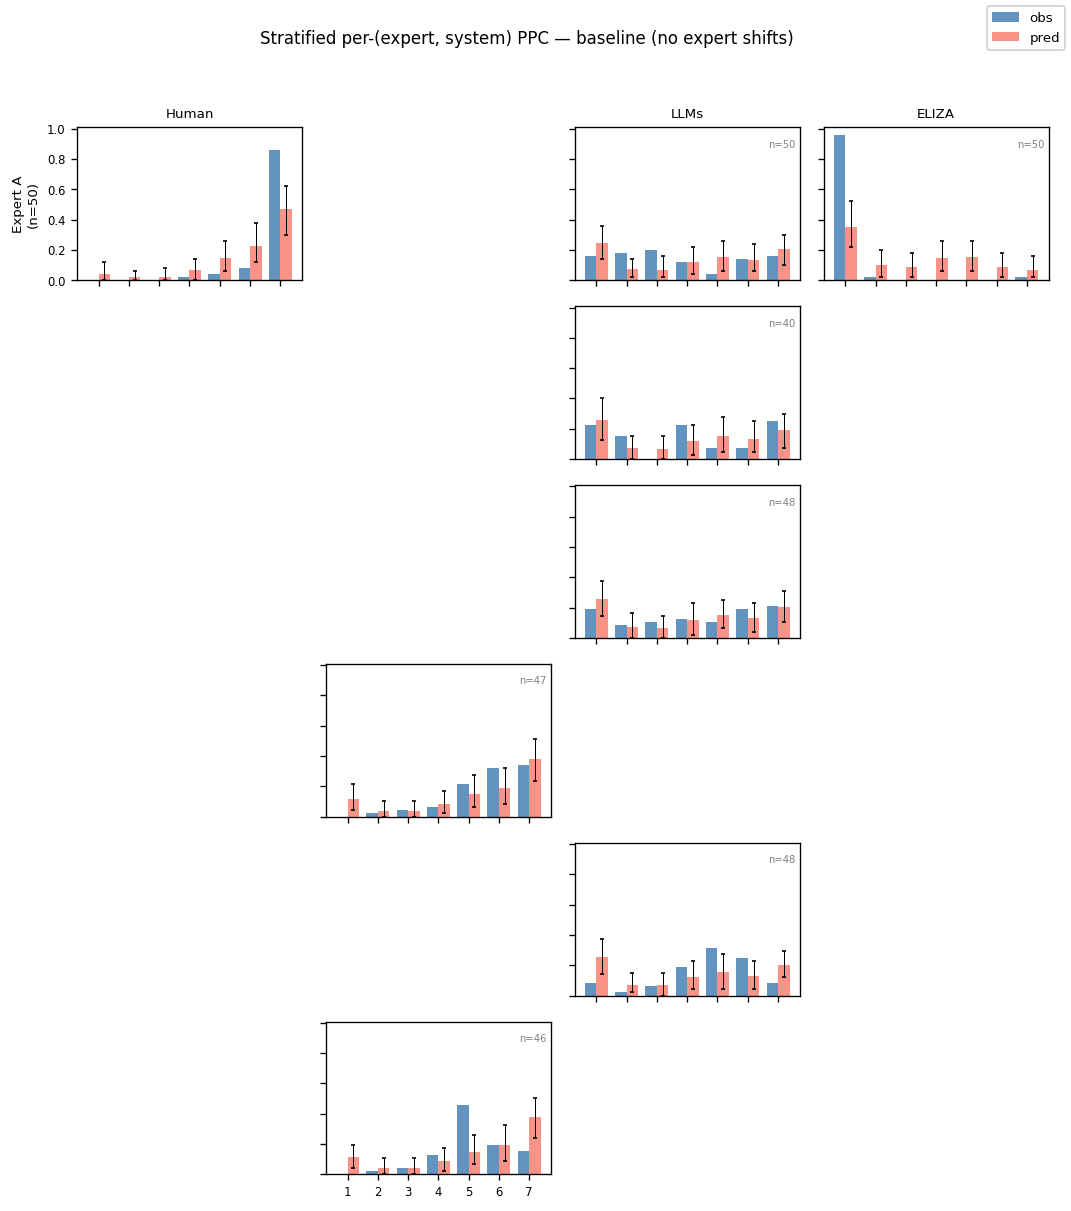

In [ ]:
expert_order_base = proc_base.expert_names  # anchor first, then alphabetical
fig, _ = plot_per_expert_system_histograms(
    ppc_base_strat,
    K=cfg_base.N_CATEGORIES,
    expert_display=anon_base,
    system_display=SYSTEM_DISPLAY,
    system_order=SYSTEM_ORDER,
    expert_order=expert_order_base,
    title="Stratified per-(expert, system) PPC — baseline (no expert shifts)",
)
fig.savefig(
    "report_figures/gwt_joint_per_expert_system_ppc_baseline.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

### 4b. Stratified PPC — tight shifts (sigma = 0.3)

In [15]:
ppc_tight_strat = per_expert_system_ppc_multisystem(
    idata_tight, builder_tight, proc_tight, n_draws=500, seed=0
)
print(f"cells: {len(ppc_tight_strat)}")
print(summarise_per_expert_system_ppc(ppc_tight_strat))

cells: 8
Expert             System                        n  obs_m           pr_m  obs_ex          pr_ex
-----------------------------------------------------------------------------------------------
Andreas Mogensen   2024 Leading Chat LLMs       40   3.00  2.97[2.35,3.62]    0.47  0.45[0.28,0.62]
Derek Shiller      2024 Leading Chat LLMs       50   2.76  2.82[2.34,3.32]    0.32  0.46[0.32,0.60]
Derek Shiller      ELIZA                        50   0.14  1.94[1.30,2.66]    0.98  0.45[0.30,0.60]
Derek Shiller      Human                        50   5.78  4.86[4.22,5.34]    0.86  0.51[0.34,0.68]
Felix Binder       2024 Leading Chat LLMs       48   3.27  3.19[2.58,3.85]    0.40  0.44[0.31,0.58]
Hayley chickens    Chicken                      47   4.79  4.49[3.96,4.96]    0.34  0.53[0.38,0.68]
Luhan Mikaelson    2024 Leading Chat LLMs       48   3.71  3.29[2.71,3.90]    0.17  0.43[0.29,0.58]
Rachael Miller     Chicken                      46   4.22  4.00[3.37,4.65]    0.15  0.46[0.30,0.61]

/Users/ryankelly/ryan-code/research/dcm-code/dcm_ppc.py:570: UserWarning: The figure layout has changed to tight


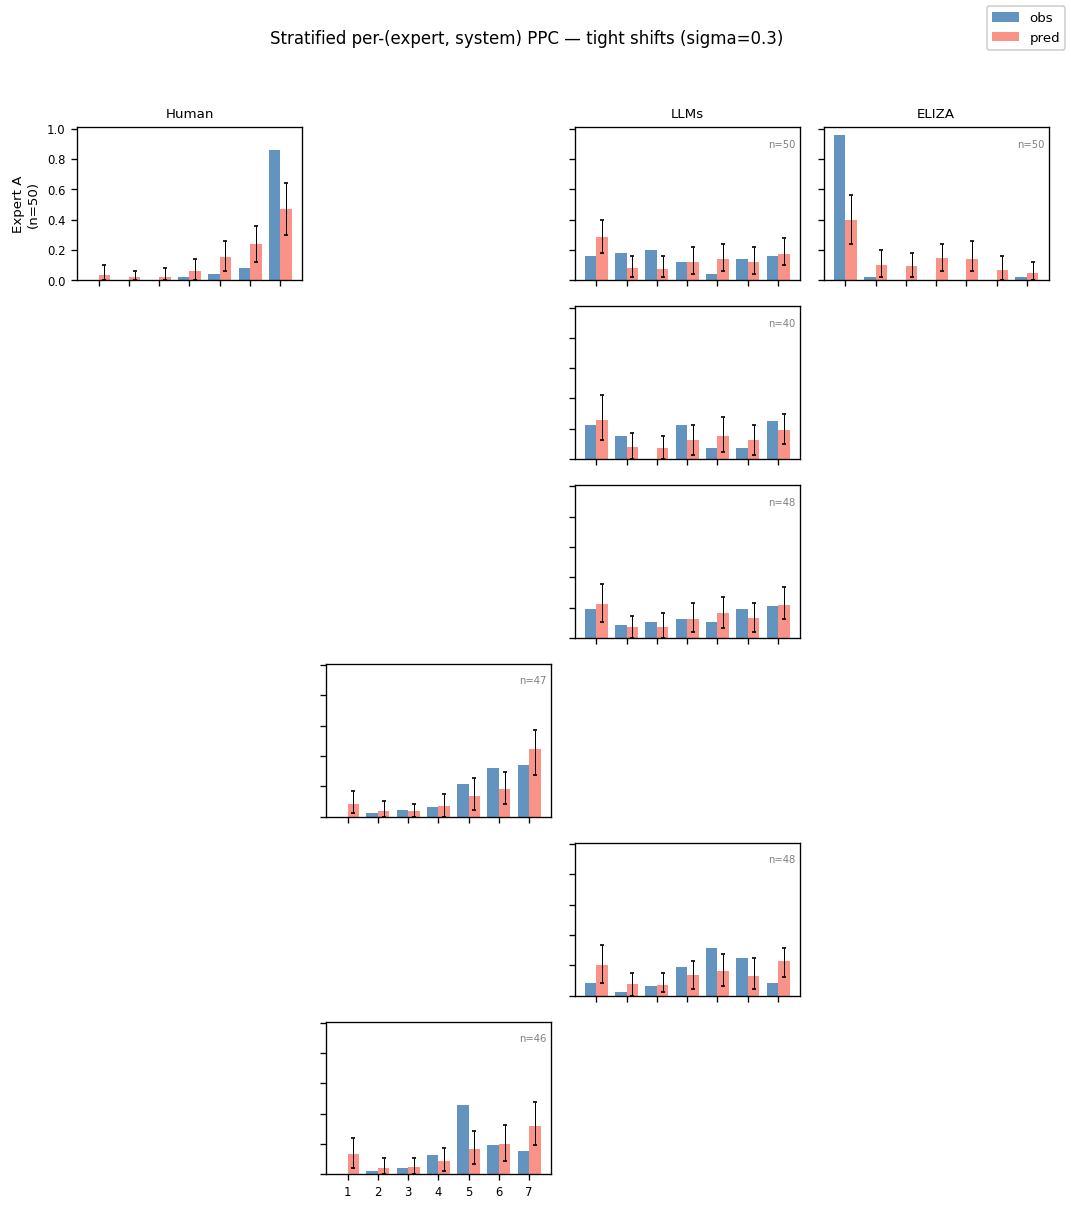

In [ ]:
expert_order_tight = proc_tight.expert_names
fig, _ = plot_per_expert_system_histograms(
    ppc_tight_strat,
    K=cfg_tight.N_CATEGORIES,
    expert_display=anon_tight,
    system_display=SYSTEM_DISPLAY,
    system_order=SYSTEM_ORDER,
    expert_order=expert_order_tight,
    title="Stratified per-(expert, system) PPC — tight shifts (sigma=0.3)",
)
fig.savefig(
    "report_figures/gwt_joint_per_expert_system_ppc_tight.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

### 4c. Scalar side-by-side: baseline vs tight shift

Differences in the mean rating per (expert, system) cell give a clean read on whether the tight-prior `b_e` actually improved expert-level location calibration. If `b_e ~ Normal(0, 0.3)` is pulled meaningfully away from 0 and the cell-level obs means come inside the predicted CIs, that's the cleanest argument for reintroducing shifts.

In [ ]:
import numpy as np

common_keys = sorted(set(ppc_base_strat.keys()) & set(ppc_tight_strat.keys()))


def cell_absdiff(ppc, key, stat):
    r = ppc[key]
    return abs(r[f"obs_{stat}"] - r[f"pred_{stat}_mean"])


print(
    f"{'(Expert, System)':<45s}  {'n':>4s}  {'Δmean_base':>11s}  {'Δmean_tight':>12s}  {'Δex_base':>10s}  {'Δex_tight':>10s}"
)
print("-" * 100)
sum_dm_base = sum_dm_tight = sum_de_base = sum_de_tight = 0.0
for key in common_keys:
    n = ppc_base_strat[key]["n_obs"]
    dm_b = cell_absdiff(ppc_base_strat, key, "mean")
    dm_t = cell_absdiff(ppc_tight_strat, key, "mean")
    de_b = cell_absdiff(ppc_base_strat, key, "extreme")
    de_t = cell_absdiff(ppc_tight_strat, key, "extreme")
    sum_dm_base += dm_b * n
    sum_dm_tight += dm_t * n
    sum_de_base += de_b * n
    sum_de_tight += de_t * n
    lbl = f"{anon_base.get(key[0], key[0])}, {SYSTEM_DISPLAY.get(key[1], key[1])}"
    print(
        f"{lbl:<45s}  {n:>4d}  {dm_b:>11.3f}  {dm_t:>12.3f}  {de_b:>10.3f}  {de_t:>10.3f}"
    )

total_n = sum(ppc_base_strat[k]["n_obs"] for k in common_keys)
print("-" * 100)
print(
    f"obs-weighted mean |Δmean_rating|:   baseline {sum_dm_base / total_n:.3f}   tight {sum_dm_tight / total_n:.3f}"
)
print(
    f"obs-weighted mean |Δextreme_prop|:  baseline {sum_de_base / total_n:.3f}   tight {sum_de_tight / total_n:.3f}"
)

# Tight-shift b_free diagnostics
if "b_free" in idata_tight.posterior.data_vars:
    bf = idata_tight.posterior["b_free"].values
    print(
        f"\nb_free posterior: mean {bf.mean():.3f}  std {bf.std():.3f}   prior sigma {cfg_tight.EXPERT_SHIFT_SIGMA}"
    )

(Expert, System)                                  n   Δmean_base   Δmean_tight    Δex_base   Δex_tight
----------------------------------------------------------------------------------------------------
Expert B, LLMs                                   40        0.020         0.027       0.023       0.028
Expert A, LLMs                                   50        0.339         0.055       0.130       0.141
Expert A, ELIZA                                  50        2.059         1.800       0.558       0.533
Expert A, Human                                  50        0.966         0.921       0.344       0.354
Expert C, LLMs                                   48        0.215         0.083       0.061       0.042
Expert D, Chicken                                47        0.585         0.300       0.154       0.192
Expert E, LLMs                                   48        0.671         0.422       0.287       0.260
Expert F, Chicken                                46        0.023         0.

### Reading the stratified plots

- **Genuine expert calibration issue** — an expert has a consistent obs vs pred mismatch across *several* systems. Reintroducing a location shift (or richer expert calibration) is justified.
- **Coverage artefact** — a mismatch only shows up in cells where the expert rated one particular system. Adding expert-level parameters risks absorbing that system's signal into expert calibration, which is the failure mode removed in nb12.
- **Tight-shift acceptability** — for the tight-`b_e` variant to be a defensible default: (1) the obs-weighted mean |Δmean_rating| should decrease vs baseline; (2) `b_free` posterior std should be meaningfully below the prior sigma (data-informed, not prior-dominated); (3) Chicken > LLMs ordering from the pooled fit in section 2 must still hold.

## 5. Bayesian workflow iteration — diagnosis and next step

Following Gelman's Bayesian workflow: log what the PPC revealed, name the most likely root cause, propose the smallest well-motivated change, and check that it can't quietly degrade the inference we care about (`P(C = 1 | data)`).

### 5.1 What the PPC revealed

**Passes**
- Ordering Human $\gg$ Chicken $>$ LLMs $\gg$ ELIZA preserved under baseline and tight-shift variants.
- 0 divergences, max R-hat = 1.000, min ESS > 4000 in both fits.
- Under the tight-prior shifts (`Normal(0, 0.3)`), `b_free` posterior std = 0.260, mean = 0.184: data is only mildly pulling shifts away from zero, and the tight-shift variant does not collapse the Chicken > LLMs ordering.

**Failures revealed only by the *stratified* PPC**

1. **Structural under-prediction of extreme categories at Derek Shiller $\times$ {Human, ELIZA}** (the only expert rating these systems):
   - Derek × Human: observed $P(r = 7) \approx 0.86$, predicted $\approx 0.47$.
   - Derek × ELIZA: observed $P(r = 1) \approx 0.98$, predicted $\approx 0.35$.
   Under the *current fitted* shared observation layer ($a \approx 1.9$, $\kappa$ clustered in roughly $[-0.3, 1.5]$), the predictive mass at the outer category when the indicator state is effectively known sits near $\approx 0.4$. This is **not** a universal limit of ordered probit — it is the compromise the current shared parameters arrive at given the full set of constraints from every cell. A location shift $b_e$ changes the *centre* of the predictive, not its *spread*; Arvo's tight-prior variant confirms this — it barely dents these two cells. The failure is in obs-layer spread under the current shared fit.

2. **Mixture bimodality vs middle-concentrated observations** at Rachael × Chicken and Luhan × LLMs. The marginalised predictive is
$$p(r = k \mid \theta) = pz1_j \, P_{\rm OP}(k \mid a, \kappa) + (1 - pz1_j) \, P_{\rm OP}(k \mid 0, \kappa),$$
Under the current shared-$a$, shared-$\kappa$ compromise, cells in which $pz1_j$ is moderate produce quasi-bimodal predictive distributions that overproduce the outer categories and struggle to match middle-concentrated observed histograms. Whether this is fixable without a structural change depends on the regime. If the affected cells' $pz1_j$ posteriors are genuinely spread across moderate values, richer observation-layer structure (per-expert noise scale, or continuous latent) is likely required. If they are near 0 or 1, a response-sharpness parameter can help. **Inspecting the $pz1$ posterior for these cells is a prerequisite to deciding which.**

**Confound removed**: the pooled per-expert PPC in section 1 appeared to motivate per-expert calibration parameters because Derek looked "extreme". The stratified plot shows his extreme pattern is entirely driven by rating Human + ELIZA (inherently at the ends of the scale). Derek × LLMs is well-fit on its own. So *introducing* expert-level parameters to chase the pooled diagnostic would have been chasing a coverage artefact.

### 5.2 Proposed next iteration — widen the shared obs-layer priors

The minimal change that addresses failure mode #1 without introducing parameters the current data can't identify:

```python
ModelConfig(
    USE_EXPERT_SHIFTS=False,     # keep validated obs structure
    A_PRIOR_SIGMA=5.0,           # was 2.0: HalfNormal(5) instead of HalfNormal(2)
    KAPPA_PRIOR_SIGMA=4.0,       # was 2.0: Normal(0, 4) — secondary, lets outer cutpoints stretch
)
```

Motivation: the baseline posterior $a \approx 1.9$ sits inside but not far from the bulk of `HalfNormal(2)`, so the prior is mildly regularising. Widening lets the data push `a` (and consequently the effective separation between $P_{\rm OP}(\cdot \mid a)$ and $P_{\rm OP}(\cdot \mid 0)$) further if that's what Derek × {Human, ELIZA} needs. Nothing else changes.

Failure mode #2 (quasi-bimodal predictive at middle-concentrated cells) is **unlikely** to be fixable by prior tuning alone — whether it can be fixed by a response-sharpness parameter or requires a richer latent-indicator structure depends on whether the affected cells' $pz1_j$ posteriors sit near the extremes (single-component regime) or in a genuinely moderate range. Either way it is a model-structure iteration and should follow the prior-widening experiment.

### 5.3 Scalability — does this model improve naturally with more data?

Two cases worth distinguishing because they give different answers:

1. **More data from the same experts on the same systems**
   - *Prior side*: yes, improves automatically. As the sample size grows the likelihood dominates and the prior's shape matters less. Wider priors make this transition cleaner.
   - *Likelihood side*: the Derek × {Human, ELIZA} misfit is *structural* — it reflects a shared obs-layer that can't produce the required spread. More data of the same kind just sharpens the wrong prediction. The residuals stay.

2. **More data from *overlapping* expert pools** (the same expert rating multiple systems)
   - This is the single biggest scalability improvement for the current architecture, and was already flagged in the week-5 report. It breaks the coverage confound and makes richer per-expert parameters (e.g. per-expert noise scale $\sigma_e$) safely identifiable — you can tell "Rachael is concentrated" apart from "chicken's indicators are ambiguous" because Rachael's calibration is grounded in data from multiple systems.

**Takeaway**: the wider-prior iteration is the right move for the *current* data, and it does not lock us out of adding per-expert parameters on top if data quality improves later. The prior widening is monotone — revert to 2.0 at any time to reproduce the current baseline.

### 5.4 Common-sense double-check: can widening obs-layer priors damage $P(C = 1 \mid \text{data})$?

This is worth an explicit check because widening priors *can* in principle let parameters drift and degrade downstream inference. For this model it's clean:

- **`a` and `$\kappa$` do not enter the tree hierarchy.** They only affect how ratings feed the indicator-presence likelihood — they don't directly see $C$ or any node's Beta parameters.
- If the data prefers the current $a \approx 1.9$, the wider prior produces the same posterior. Zero effect on $C$.
- If the data prefers a larger $a$, each rating becomes *more* informative about indicator presence, so $C$ posteriors become **sharper**, not looser. The central tendency only moves to the extent the data genuinely supports a different $q_j$ — which is the direction we *want* inference to move.
- The pathological failure mode would be $a \to \infty$ identifiability collapse. `HalfNormal(2)` already allows $a \le 6$ with non-trivial mass and the posterior didn't drift there; `HalfNormal(5)` will not either.

**Falsifiable prediction for cell 5.6**: Chicken $C$ posterior median within $\pm 0.05$ of the baseline 0.273, LLMs within $\pm 0.05$ of 0.109, ordering preserved, convergence clean, `a` posterior mean at most mildly larger. Cell 5.6 asserts the ordering and prints the Δs.

### 5.5 Run the wider-prior fit

~75 minutes. Nothing depends on this finishing before the next cells can be read — they're all defined in terms of the already-existing `idata_base` and the new `idata_wide`.

In [3]:
cfg_wide = ModelConfig(
    USE_EXPERT_SHIFTS=False,
    A_PRIOR_SIGMA=5.0,
    KAPPA_PRIOR_SIGMA=4.0,
    NUM_SAMPLES=2000,
    NUM_TUNE=1500,
    NUM_CHAINS=4,
    TARGET_ACCEPT=0.9,
)

t0 = time.time()
idata_wide, builder_wide, proc_wide = fit_stance_multisystem(
    stance_data, cfg_wide, SYSTEM_CONFIGS
)
print(f"\nWider-prior fit: {time.time() - t0:.0f}s")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [chicken__global_workspace_theory_C, 2024_leading_chat_llms__global_workspace_theory_C, a, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic_representations_beta_pres, isomorphic_representations_beta_abs, somatotopic_neural_maps_beta_pres, somato

Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 437 seconds.



Wider-prior fit: 4768s


In [ ]:
# --- Per-system C, convergence, obs-layer params ---
stance_vn = builder_wide.node_to_varname[STANCE]
post_w = idata_wide.posterior

print("Per-system P(C=1 | data) — wider obs-layer priors:")
wide_summary = {}
for sys_name, c_fixed in SYSTEM_CONFIGS:
    sp = builder_wide._sys_prefix(sys_name)
    c_key = f"{sp}__{stance_vn}_C"
    if c_key in post_w:
        d = post_w[c_key].values.flatten()
        med, lo, hi = (
            float(np.median(d)),
            float(np.percentile(d, 3)),
            float(np.percentile(d, 97)),
        )
        wide_summary[sys_name] = (med, lo, hi)
        print(f"  {sys_name:<25s}  {med:.3f}  [{lo:.3f}, {hi:.3f}]")
    else:
        wide_summary[sys_name] = (c_fixed, c_fixed, c_fixed)
        print(f"  {sys_name:<25s}  {c_fixed:.3f}  (ref)")

n_div = int(idata_wide.sample_stats["diverging"].values.sum())
diag = az.summary(idata_wide, var_names=["a", "kappa"], kind="diagnostics")
print(
    f"\nDivergences: {n_div}   max R-hat: {float(diag['r_hat'].max()):.3f}   min ESS: {float(diag['ess_bulk'].min()):.0f}"
)
print(f"Shared a: {float(post_w['a'].mean()):.3f}  (baseline 1.906)")
kappa_vals = post_w["kappa"].values.reshape(-1, cfg_wide.N_CATEGORIES - 1)
print(f"Kappa means: [{', '.join(f'{v:.2f}' for v in kappa_vals.mean(axis=0))}]")

# --- Sanity check: falsifiable prediction from section 5.4 ---
BASELINE_C = {"Chicken": 0.273, "2024 Leading Chat LLMs": 0.109}
TOL = 0.05
print("\nSanity check vs baseline (±0.05 tolerance on median):")
ok = True
for sys_name, base in BASELINE_C.items():
    wmed, _, _ = wide_summary[sys_name]
    delta = wmed - base
    flag = "OK" if abs(delta) <= TOL else "OUTSIDE TOLERANCE"
    print(
        f"  {sys_name:<25s}  wide {wmed:.3f}  base {base:.3f}  Δ {delta:+.3f}  {flag}"
    )
    if abs(delta) > TOL:
        ok = False
assert wide_summary["Chicken"][0] > wide_summary["2024 Leading Chat LLMs"][0], (
    "ORDERING BROKEN: Chicken should be > LLMs"
)
print("\nOrdering Chicken > LLMs: OK")
if not ok:
    print(
        "\nWARNING: one or more C posteriors moved outside ±0.05. Investigate before accepting."
    )
else:
    print("Falsifiable prediction passed.")

Per-system P(C=1 | data) — wider obs-layer priors:
  Human                      0.999  [0.999, 0.999]
  Chicken                    0.238  [0.014, 0.670]
  2024 Leading Chat LLMs     0.080  [0.004, 0.349]
  ELIZA                      0.001  [0.001, 0.001]

Divergences: 0   max R-hat: 1.000   min ESS: 6439
Shared a: 1.943  (baseline 1.906)
Kappa means: [-0.30, -0.02, 0.22, 0.65, 1.27, 1.92]

Sanity check vs baseline (±0.05 tolerance on median):
  Chicken                    wide 0.238  base 0.273  Δ -0.035  OK
  2024 Leading Chat LLMs     wide 0.080  base 0.109  Δ -0.029  OK

Ordering Chicken > LLMs: OK
Falsifiable prediction passed.


Expert             System                        n  obs_m           pr_m  obs_ex          pr_ex
-----------------------------------------------------------------------------------------------
Andreas Mogensen   2024 Leading Chat LLMs       40   3.00  3.00[2.35,3.62]    0.47  0.45[0.30,0.60]
Derek Shiller      2024 Leading Chat LLMs       50   2.76  3.08[2.62,3.56]    0.32  0.45[0.32,0.58]
Derek Shiller      ELIZA                        50   0.14  2.16[1.48,2.82]    0.98  0.42[0.28,0.60]
Derek Shiller      Human                        50   5.78  4.83[4.24,5.32]    0.86  0.51[0.36,0.68]
Felix Binder       2024 Leading Chat LLMs       48   3.27  3.04[2.50,3.60]    0.40  0.46[0.33,0.60]
Hayley chickens    Chicken                      47   4.79  4.21[3.68,4.68]    0.34  0.49[0.34,0.64]
Luhan Mikaelson    2024 Leading Chat LLMs       48   3.71  3.02[2.52,3.58]    0.17  0.45[0.31,0.58]
Rachael Miller     Chicken                      46   4.22  4.21[3.72,4.74]    0.15  0.49[0.35,0.63]


/Users/ryankelly/ryan-code/research/dcm-code/dcm_ppc.py:570: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.96) if title else None)


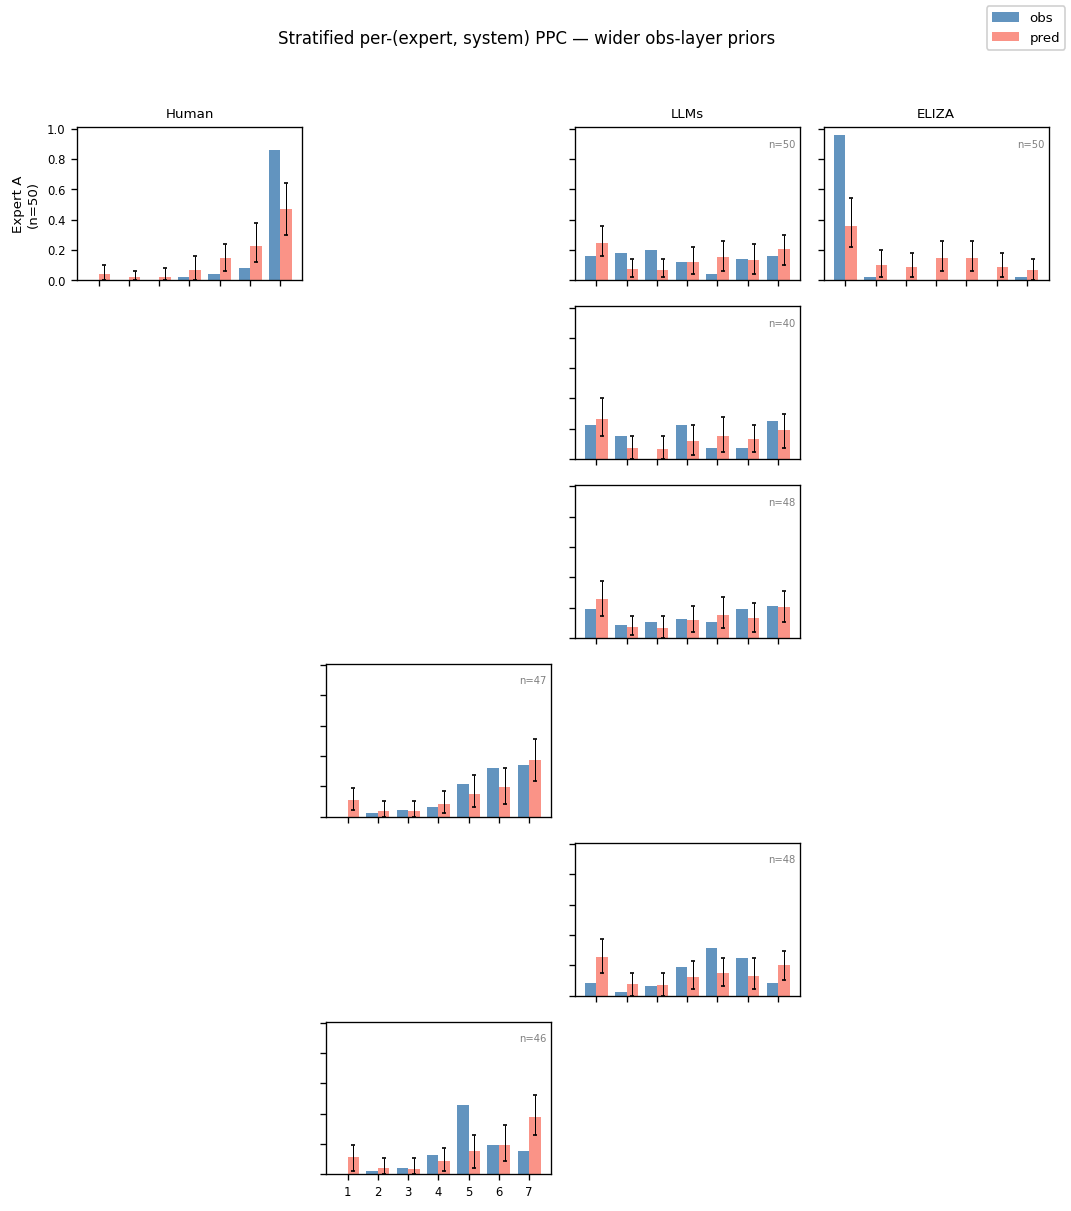

In [ ]:
# --- Stratified PPC under the wider-prior fit ---
ppc_wide_strat = per_expert_system_ppc_multisystem(
    idata_wide, builder_wide, proc_wide, n_draws=500, seed=0
)

anon_wide = {
    name: f"Expert {letter}"
    for letter, name in zip(string.ascii_uppercase, proc_wide.expert_names)
}

print(summarise_per_expert_system_ppc(ppc_wide_strat))

fig, _ = plot_per_expert_system_histograms(
    ppc_wide_strat,
    K=cfg_wide.N_CATEGORIES,
    expert_display=anon_wide,
    system_display=SYSTEM_DISPLAY,
    system_order=SYSTEM_ORDER,
    expert_order=proc_wide.expert_names,
    title="Stratified per-(expert, system) PPC — wider obs-layer priors",
)
fig.savefig(
    "report_figures/gwt_joint_per_expert_system_ppc_wide.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [ ]:
# --- Did widening the priors actually reduce the extreme-mass misfit? ---
print("Extreme-category (P(r in {1, 7})) predictions — baseline vs wider-prior:\n")
print(
    f"{'Cell':<40s} {'n':>4s}  {'obs_ex':>7s}  {'base_pred':>10s}  {'wide_pred':>10s}  {'Δ (wide-base)':>14s}"
)
print("-" * 95)
focus_keys = [
    ("Derek Shiller", "Human"),
    ("Derek Shiller", "ELIZA"),
    ("Derek Shiller", "2024 Leading Chat LLMs"),
    ("Hayley chickens", "Chicken"),
    ("Rachael Miller", "Chicken"),
    ("Luhan Mikaelson", "2024 Leading Chat LLMs"),
]
for key in focus_keys:
    if key not in ppc_base_strat or key not in ppc_wide_strat:
        continue
    ob = ppc_base_strat[key]
    wd = ppc_wide_strat[key]
    lbl = f"{key[0]} x {SYSTEM_DISPLAY.get(key[1], key[1])}"
    print(
        f"{lbl:<40s} {ob['n_obs']:>4d}  {ob['obs_extreme']:>7.3f}  "
        f"{ob['pred_extreme_mean']:>10.3f}  {wd['pred_extreme_mean']:>10.3f}  "
        f"{wd['pred_extreme_mean'] - ob['pred_extreme_mean']:+14.3f}"
    )

# Aggregate obs-weighted |Δ| vs observations
common = sorted(set(ppc_base_strat) & set(ppc_wide_strat))


def ewavg(ppc, stat):
    num = sum(
        abs(ppc[k][f"obs_{stat}"] - ppc[k][f"pred_{stat}_mean"]) * ppc[k]["n_obs"]
        for k in common
    )
    den = sum(ppc[k]["n_obs"] for k in common)
    return num / den


print("\nobs-weighted mean |obs - pred|  (lower is better):")
print(
    f"  |Δmean_rating|:   baseline {ewavg(ppc_base_strat, 'mean'):.3f}   wider {ewavg(ppc_wide_strat, 'mean'):.3f}"
)
print(
    f"  |Δextreme_prop|:  baseline {ewavg(ppc_base_strat, 'extreme'):.3f}   wider {ewavg(ppc_wide_strat, 'extreme'):.3f}"
)

Extreme-category (P(r in {1, 7})) predictions — baseline vs wider-prior:

Cell                                        n   obs_ex   base_pred   wide_pred   Δ (wide-base)
-----------------------------------------------------------------------------------------------


NameError: name 'ppc_base_strat' is not defined

### 5.6 Reading the wider-prior fit — decision tree

**Best-case outcome**: `a` moves up to ~2.5–3 AND Derek × {Human, ELIZA} extreme predictions close a visible chunk of the gap (say from 0.35–0.47 toward 0.55–0.65). Then: prior was binding, widening was the right call, make it the default, and log "middle-concentrated cells (Rachael, Luhan) still misfit — requires model-structure change" as the next workflow iteration.

**Null outcome**: `a` barely moves (stays near 1.9), Derek cells barely change, Chicken/LLMs C essentially unchanged. Then: data doesn't want a larger `a` given the current shared-obs-layer constraints. The Derek misfit is not fixable by prior tuning; next iteration has to be structural. Two candidates worth weighing:
- **Per-expert noise scale** $\sigma_e$ — latent signal $s = b_e + z \cdot a + \sigma_e \varepsilon$. Small $\sigma_e$ sharpens each component of the $pz1$-mixture, large $\sigma_e$ blurs it. The bimodality itself comes from the binary $z$, not from $\sigma_e$ — so $\sigma_e$ is **not** a universal middle-vs-extreme dial. It is most plausibly useful in cells where $pz1$ is near 0 or 1 (the mixture is effectively single-component, and $\sigma_e$ concentrates predicted mass onto the correct extreme). Identification is cleanest on reference-system cells (Human, ELIZA) where $pz1$ is anchored by the reference credence.
- **Continuous latent $z$** — replace the binary indicator-presence variable with a continuous one. Bigger change, better generative story, more expressive predictive. Longer implementation.

**Red-flag outcome**: C posteriors for Chicken or LLMs move outside the ±0.05 tolerance in cell 5.6. Stop and investigate — either the wider prior uncovered an identifiability path we missed, or the baseline posterior was prior-constrained for reasons worth understanding. Don't silently accept.

### 5.7 What this implies for the next data-collection round

The two structural failures above (Derek × Human/ELIZA spread, middle-concentrated cells) are primarily symptoms of **non-overlapping expert pools across systems**. The single biggest design improvement for the *next* survey is therefore:

- Require each expert to rate at least two systems, ideally with one of those being a reference system (Human or ELIZA).

With that in place, the stratified PPC loses its confound entirely and we can safely add per-expert calibration parameters (either $\sigma_e$ or richer) on top of the wider-prior model without any of the coverage worries that drove us to remove expert shifts in section 1 of the week-5 report. The current wider-prior iteration is a clean stepping stone: it improves what it can improve with the present data, and it doesn't block the richer model later.

## 5.8 Observed outcome of the wide-prior fit and updated next step

### What the fit actually produced

| | baseline | wider-prior variant | change |
|---|---:|---:|---:|
| shared $a$ | 1.906 | 1.943 | +0.037 (sampling noise) |
| $\kappa$ (outer) | ... | $\kappa_6 \approx 1.92$ | mildly stretched |
| Chicken $C$ median | 0.273 | 0.238 | $-0.035$ (inside $\pm 0.05$ tolerance) |
| LLMs $C$ median | 0.109 | 0.080 | $-0.029$ (inside $\pm 0.05$ tolerance) |
| obs-weighted $\lvert\Delta\text{mean}\rvert$ | 0.635 | 0.624 | $\approx 2\%$ — noise |
| obs-weighted $\lvert\Delta\text{extreme}\rvert$ | 0.241 | 0.242 | unchanged |
| ordering, divergences, R-hat, ESS | clean | clean | all green |

Per-cell stratified PPC is visually indistinguishable from baseline. Derek × {Human, ELIZA} extreme-category predictions are essentially unchanged.

### Interpretation (updated, with the overstatements corrected)

1. **The `a` prior was not materially binding.** Under `HalfNormal(5)` the posterior barely moves from its `HalfNormal(2)` value. We can rule out "the prior was holding `a` down" as an explanation for the Derek/Human-ELIZA misfit.
2. **The `$\kappa$` prior was at most mildly binding at the outer cutpoints.** $\kappa_6$ stretched a little, but the downstream effect on per-cell predictions is effectively zero.
3. **The shared obs layer is at its compromise optimum under the current architecture.** The remaining misfit is structural-given-the-current-structure, not prior-constrained. (This is narrower than saying "ordered probit cannot do this in principle" — which would be too strong. It says the current shared $a$, $\kappa$ parameters, fitted against the full set of cells, cannot also fit Derek × {Human, ELIZA} or Rachael/Luhan.)
4. **Both $C$ posteriors moved slightly toward the prior mean** (1/6 ≈ 0.167). Within tolerance, but directionally worth noting — a wider obs layer absorbs a touch more of the rating variance, pulling a touch of signal out of the tree. This becomes the reference baseline against which any per-expert parameter experiment should be judged.

### Before proposing a $\sigma_e$ experiment: inspect $pz1$ for the problematic cells

The value of a per-expert noise scale $\sigma_e$ depends critically on *which regime* the affected cells sit in under the current posterior:

- **Single-component regime** ($pz1_j$ near 0 or 1 for most indicators in the cell): the mixture is effectively a single ordered-probit distribution and $\sigma_e$ can concentrate mass on the correct extreme. $\sigma_e$ is plausibly useful here.
- **Genuinely moderate regime** ($pz1_j$ spread across the middle): the mixture is a true two-component mixture and $\sigma_e$ does not give us a free "middle-concentration" dial. A richer latent-indicator model is more likely to be needed.

The four cells that matter are:
- **Derek × Human** (reference anchor, expected single-component near 1 by construction, but worth verifying — tree structure can pull individual indicators off the top)
- **Derek × ELIZA** (reference anchor, expected single-component near 0, same caveat)
- **Rachael × Chicken** (non-reference, regime unknown — this decides whether $\sigma_e$ is a candidate fix for the middle-mass misfit or a dead end for it)
- **Luhan × LLMs** (same)

The next cell runs the inspection against your live `idata_wide`.

In [ ]:
# Prerequisite to any sigma_e experiment: classify pz1 regime for the
# problematic cells under the current (wider-prior) posterior.
importlib.reload(dcm_ppc)
from dcm_ppc import inspect_pz1_for_cell, classify_pz1_regime

TARGET_CELLS = [
    ("Derek Shiller", "Human"),
    ("Derek Shiller", "ELIZA"),
    ("Rachael Miller", "Chicken"),
    ("Luhan Mikaelson", "2024 Leading Chat LLMs"),
]

pz1_inspection = {}

for expert_name, system_name in TARGET_CELLS:
    rows = inspect_pz1_for_cell(idata_wide, builder_wide, proc_wide, expert_name, system_name)
    reg = classify_pz1_regime(rows)
    pz1_inspection[(expert_name, system_name)] = (rows, reg)

    lbl = f"{expert_name} x {SYSTEM_DISPLAY.get(system_name, system_name)}"
    print(f"=== {lbl} ===")
    print(f"  indicators rated: {reg['n_indicators']}")
    print(f"  near 0 (median < 0.1): {reg['near_0']}")
    print(f"  near 1 (median > 0.9): {reg['near_1']}")
    print(f"  moderate           :    {reg['moderate']}")
    print(f"  frac single-component (near 0 or 1): {reg['frac_single_component']:.2f}")
    # Quick distribution sketch
    medians = sorted(r["median"] for r in rows)
    q25 = medians[len(medians) // 4] if medians else float("nan")
    q50 = medians[len(medians) // 2] if medians else float("nan")
    q75 = medians[3 * len(medians) // 4] if medians else float("nan")
    print(f"  pz1 median quartiles: {q25:.2f}, {q50:.2f}, {q75:.2f}")
    print()

### 5.9 Conditional decision rule for $\sigma_e$

Use the inspection output directly to choose the next step. The rule is stated in advance so the choice is not made post-hoc.

- **Derek × Human and Derek × ELIZA**: if `frac_single_component ≥ 0.85` in both — the reference-anchored cells are cleanly single-component, and $\sigma_e$ has a coherent mechanism by which it could close their extreme-mass gap. If `frac_single_component < 0.85` in either — tree structure is pulling enough indicators away from the expected extreme that $\sigma_e$ would only partially operate in its intended regime even on the ref anchors; in that case $\sigma_e$ is not the right move and the next iteration should be a richer latent model.
- **Rachael × Chicken and Luhan × LLMs**: whatever the outcome, this pins down whether $\sigma_e$ has any claim to fixing those cells or whether we should explicitly log that as a case for the richer latent iteration.

Interpretation shorthand:

| Derek ref cells | Rachael/Luhan | Recommended next step |
|---|---|---|
| both cleanly single-component | either regime | **A**. Derek-only $\sigma_{\text{Derek}}$ experiment — narrow, falsifiable test |
| both cleanly single-component, and Rachael/Luhan are also single-component | — | **B** is on the table, but only after A succeeds |
| Derek ref cells not single-component | — | **C**. Defer $\sigma_e$; next structural move is a richer latent-indicator model |

The default recommendation, before the inspection runs, is **A** (Derek-only $\sigma_{\text{Derek}}$): it is the smallest defensible test, it sits in the cleanest identifiability regime (reference anchors pin $pz1$, so $\sigma_{\text{Derek}}$ cannot absorb system signal on those cells), and it decides the question without committing to a hierarchical model. Option **B** (hierarchical $\sigma_e$ across all experts) is only justified after A has shown the mechanism actually closes Derek's gap.